In [ ]:
# import os
# import glob
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.sparse as sp
# from scipy.stats import pearsonr
# from tqdm import tqdm
# import time
# from collections import Counter
# from matplotlib.patches import Patch
# from scipy.spatial.distance import cdist
# import re
# import scipy
# import warnings

# from scipy.stats import zscore
# from matplotlib.colors import LinearSegmentedColormap
# from scipy.cluster.hierarchy import linkage, fcluster
# from collections import defaultdict
# import cuml
# from cuml.metrics import pairwise_distances

# import rmm
# import cupy
# import cudf
# import cupy as cp
# import cvxpy as cpv
# from rmm.allocators.cupy import rmm_cupy_allocator
# from sklearn.feature_extraction.text import CountVectorizer
# from cuml.linear_model import ElasticNet
# import anndata as an
# import scanpy as sc
# from scanpy.tools._utils import get_init_pos_from_paga 
# import rapids_singlecell as rsc
# import scvi

# import torch
# from torchnmf.nmf import NMF

# # Enable `managed_memory`
# rmm.reinitialize(
#     managed_memory=True,
#     pool_allocator=False,
# )
# cp.cuda.set_allocator(rmm_cupy_allocator)

In [1]:
# import os
# import glob
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.sparse as sp
# import time
# #import gget
# import scipy
# from scipy.spatial.distance import pdist, squareform
# from tqdm import tqdm

# import anndata as an
# import scanpy as sc
# import scanpy.external as sce
# from scanpy.tools._utils import get_init_pos_from_paga
# import rapids_singlecell as rsc
# import scvi

# import cupy as cp
# from cuml.metrics import pairwise_distances
# from cuml.manifold import TSNE
# from cuml.decomposition import PCA

# sc.settings.verbosity = 3

In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load Gene Metadata

In [3]:
%%time
fpath = "../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 129 ms, sys: 16.8 ms, total: 145 ms
Wall time: 151 ms


# Load our data

In [4]:
%%time
# h5ad built in Heamtokytos/anndatas/bm_scfib_hsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/three_libraries_new.h5ad"
adata = sc.read_h5ad(fpath)
adata = adata[:, adata.var_names.isin(protein_coding)].copy()
adata.X = adata.layers['raw_counts'].copy()

# define new annotation columns
cluster_map = {
    'initial':'initial',
    'R2':'R2',
    'MPP':'MPP',
    'R1':'R1',
    'HSC':'HSC',
    'R3':'R3',
    'CLP':'CLP',
    'LMPP':'LMPP',
    'MEG-ERY':'MEG-ERY',
    'CMP':'CMP',
    'GMP':'GMP',
}

adata.obs['cell_type'] = adata.obs['label'].map(cluster_map)
adata = adata[adata.obs['cell_type'].notna(), :].copy()

# aggregrate
agg = 'sum'
adata = sc.get.aggregate(
    adata,
    by='cell_type',
    func=agg,
)

adata.X = adata.layers[agg]
rsc.get.anndata_to_GPU(adata)
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()
rsc.pp.normalize_total(adata, target_sum=1)
adata.layers['probs'] = adata.X.copy()
rsc.get.anndata_to_CPU(adata)

adata

CPU times: user 4.94 s, sys: 6.73 s, total: 11.7 s
Wall time: 26.8 s


AnnData object with n_obs × n_vars = 11 × 15147
    obs: 'cell_type'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'Chromosome', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mito', 'filter_pass'
    uns: 'log1p'
    layers: 'sum', 'log_norm', 'probs'

# Load other datasets

In [5]:
datasets = {
    'Gomes 2018' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/gomes_2018/gomes.h5ad",
        'annotation_column' : 'cell_type',
        'layer' : 'raw_counts',
    },
    'Pellin 2019' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/pellin_2019/pellin.anndata.h5ad",
        'annotation_column' : 'dataset',
        'layer' : 'raw_counts',
    },
    'Georgolopoulos 2021' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/georgolopoulos_2021/anndata.h5ad",
        'annotation_column' : 'populations',
        'layer' : 'matrix',
    },
    'Weng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/weng_2024/scanpy_objects/young1_all_t2.h5ad",
        'annotation_column' : 'STD.CellType',
        'layer' : 'raw_counts',
    },

    'Ng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/Ng_2024_raw.h5ad",
        'annotation_column' : 'celltype',
        'layer' : 'raw_counts',
    },
    'Setty 2019' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/anndata.h5ad",
        'annotation_column' : 'cell_type',
        'layer' : 'raw_counts',
    },
}

In [6]:
%%time

data = {
    'Our data' : adata.copy()
}

for dataset, params in datasets.items():
    print(f"\n--- Loading dataset: {dataset} ---")
    t0 = time.time()

    fpath = params['file_path']
    column = params['annotation_column']
    layer = params['layer']

    print(f"\t - Reading file: {fpath}")
    bdata = sc.read_h5ad(fpath)
    bdata.var_names_make_unique()
    print(f"\t - Read complete. Shape: {bdata.shape}")

    # Annotate cell type and filter
    bdata.obs['cell_type'] = bdata.obs[column].copy()
    n_total = bdata.shape[0]
    bdata = bdata[bdata.obs['cell_type'].notna(), :].copy()
    n_filtered = bdata.shape[0]
    print(f"\t - Cells before filtering: {n_total}, after filtering: {n_filtered}")

    # Select layer if specified
    if layer is not None:
        print(f"\t - Using layer: {layer}")
        bdata.X = bdata.layers[layer].copy()
    else:
        print("\t - Using .X as is (no layer specified)")

    bdata = bdata[:, bdata.var_names.isin(protein_coding)].copy()
    bdata.X = bdata.X.astype('float32')
    rsc.get.anndata_to_GPU(bdata)
    rsc.pp.filter_genes(bdata, min_counts=10)
    
    print(f"\t - Filtered genes. Final Shape: {bdata.shape}")

    n_genes = bdata.shape[1]
    n_cell_types = bdata.obs['cell_type'].nunique()
    cell_types = sorted(bdata.obs['cell_type'].unique())
    print(f"\t - Unique cell types ({n_cell_types}): {cell_types[:5]}{' ...' if n_cell_types > 5 else ''}")

    t1 = time.time()
    print(f"\t - Time to load and process: {t1 - t0:.2f} seconds")

    # aggregate
    rsc.get.anndata_to_CPU(bdata)
    agg = 'sum'
    bdata = sc.get.aggregate(
        bdata,
        by='cell_type',
        func=agg,
    )
    
    bdata.X = bdata.layers[agg]
    rsc.get.anndata_to_GPU(bdata)
    rsc.pp.normalize_total(bdata, target_sum=1e4)
    rsc.pp.log1p(bdata)
    bdata.layers['log_norm'] = bdata.X.copy()
    rsc.pp.normalize_total(bdata, target_sum=1)
    bdata.layers['probs'] = bdata.X.copy()
    rsc.get.anndata_to_CPU(bdata)

    data[dataset] = bdata.copy()

print('done')


--- Loading dataset: Gomes 2018 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/gomes_2018/gomes.h5ad


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


	 - Read complete. Shape: (286, 56269)
	 - Cells before filtering: 286, after filtering: 286
	 - Using layer: raw_counts
filtered out 3550 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (286, 13492)
	 - Unique cell types (5): ['DAY15', 'DAY2', 'DAY25', 'HDF', 'UCB']
	 - Time to load and process: 1.04 seconds

--- Loading dataset: Pellin 2019 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/pellin_2019/pellin.anndata.h5ad
	 - Read complete. Shape: (21412, 20582)
	 - Cells before filtering: 21412, after filtering: 21412
	 - Using layer: raw_counts
filtered out 2475 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (21412, 13979)
	 - Unique cell types (11): ['CMP', 'GMP', 'HSC', 'LinNegCD34NegCD164high', 'LinNegCD34NegCD164low'] ...
	 - Time to load and process: 54.42 seconds

--- Loading dataset: Georgolopoulos 2021 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


	 - Read complete. Shape: (53511, 36601)
	 - Cells before filtering: 53511, after filtering: 53511
	 - Using layer: matrix
filtered out 4050 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (53511, 13384)
	 - Unique cell types (7): ['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2'] ...
	 - Time to load and process: 39.77 seconds

--- Loading dataset: Weng 2024 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/weng_2024/scanpy_objects/young1_all_t2.h5ad
	 - Read complete. Shape: (25442, 36601)
	 - Cells before filtering: 25442, after filtering: 25252
	 - Using layer: raw_counts
filtered out 3255 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (25252, 14179)
	 - Unique cell types (20): ['B', 'CD4', 'CD8', 'CLP', 'CMP'] ...
	 - Time to load and process: 10.31 seconds

--- Loading dataset: Ng 2024 ---
	 - Reading file: /scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/Ng_2024_raw.h5ad
	 - 

# Merge into a single object

In [7]:
%%time
adatas = [v for v in data.values()]
keys = [k for k in data.keys()]

# Concatenate into one AnnData object, with a new column in .obs named 'batch'
adata = sc.concat(adatas, join="outer", label="batch", keys=keys)
adata

CPU times: user 92 ms, sys: 20.6 ms, total: 113 ms
Wall time: 134 ms


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 82 × 16720
    obs: 'cell_type', 'batch'
    layers: 'sum', 'log_norm', 'probs'

In [8]:
adata.obs["cell_type"].value_counts()

cell_type
GMP                         3
CMP                         3
MPP                         3
HSC                         3
CLP                         2
                           ..
initial                     1
megakaryocyte progenitor    1
monocyte progenitor         1
myeloid progenitor          1
pDC                         1
Name: count, Length: 70, dtype: int64

# Metadata Clean up

In [30]:
label_map = {
    # Experimental / Condition Labels
    # 'C4': 'Control',
    # 'C5': 'Control',
    # 'R1': '5TF (R1)',
    # 'R2': '5TF (R2)',
    # 'R3': '5TF (R3)',
    'initial':'initial',
    'R2':'5TF (R2)',
    'MPP':'MPP',
    'R1':'5TF (R1)',
    'HSC':'HSC',
    'R3':'5TF (R3)',
    'CLP':'CLP',
    'LMPP':'LMPP',
    'MEG-ERY':'MEP',
    'CMP':'CMP',
    'GMP':'GMP',
    'DAY2': '3TF (Day 2)',
    'DAY15': '3TF (Day 15)',
    'DAY25': '3TF (Day 25)',
    'Control': 'Control',
    'HDF': 'HDF',
    'UCB': 'UCB',

    # Hematopoietic Stem and Progenitor Cells (HSPCs)
    'HSC': 'HSC',
    'Refined.HSC': 'HSC',
    'hematopoietic stem cell': 'HSC',
    'HSPC': 'HSPC',
    'HSPC1': 'HSPC',
    'HSPC2': 'HSPC',
    'HSPC3': 'HSPC',
    'MPP': 'MPP',
    'MPP1': 'MPP',
    'MPP2': 'MPP',
    'LMPP': 'LMPP',
    'hematopoietic multipotent progenitor': 'MPP',
    'CLP': 'CLP',
    'common lymphoid progenitor': 'CLP',
    'CMP': 'CMP',
    'GMP': 'GMP',
    'MEP': 'MEP',
    'MLP': 'MLP',
    'MDP': 'MDP',
    'dendtritic progenitor': 'DCP',
    'EryP': 'EryP',
    'erythroid progenitor': 'EryP',
    'MKP': 'MKP',
    'megakaryocyte progenitor': 'MKP',
    'MonoP': 'MonoP',
    'Mye Pro1': 'MyP',
    'Mye Pro2': 'MyP',
    'monocyte progenitor': 'MonoP',
    'myeloid progenitor': 'MyP',
    'EMK Pro1': 'EMKP',
    'EMK Pro2': 'EMKP',
    'PreBNK': 'PreBNK',
    'ProB': 'ProB',

    # Mature and Differentiated Cell Types
    'Ery1': 'Ery',
    'Ery2': 'Ery',
    'Mk1': 'MK',
    'Mk2': 'MK',
    'Mega': 'MK',
    'Mono': 'Mono',
    'Gran': 'Gran',
    'Eos': 'Eos',
    'B': 'B',
    'Plasma': 'Plasma',
    'NK': 'NK',
    'CD4': 'CD4',
    'CD8': 'CD8',
    'cDC': 'cDC',
    'pDC': 'pDC',
    
    # Lineage Negative Population
    'LinNegCD34NegCD164high': 'LinNeg',
    'LinNegCD34NegCD164low': 'LinNeg',
    'LinNegCD34PosCD164Pos': 'LinNeg',
    'LinNegCD34lowCD164high': 'LinNeg',

    # Stromal and Endothelial Cells
    # 'Strom1': 'Endo/Stromal',
    # 'Strom2': 'Endo/Stromal',
    # 'Strom3': 'Endo/Stromal',
    # 'Strom4': 'Endo/Stromal',
    # 'Venous': 'Endo/Stromal',
    # 'Endo': 'Endo',
    # 'Art1': 'Art',
    # 'Art2': 'Art',
    # 'Hemogenic': 'Hemogenic',
    
    'Strom1': 'Stromal',
    'Strom2': 'Stromal',
    'Strom3': 'Stromal',
    'Strom4': 'Stromal',
    'Venous': 'Endothelium',
    'Endo': 'Endothelial',
    'Art1': 'Endothelium',
    'Art2': 'Endothelium',
    'Hemogenic': 'Hemogenic',
}

adata.obs['label'] = adata.obs['cell_type'].map(label_map)
adata.obs['label'].value_counts()

label
MPP             6
HSC             5
HSPC            4
LinNeg          4
Stromal         4
GMP             3
MyP             3
Endothelium     3
MK              3
MEP             3
CMP             3
CLP             3
MKP             2
Mono            2
EMKP            2
Ery             2
EryP            2
LMPP            2
5TF (R1)        1
5TF (R2)        1
3TF (Day 2)     1
initial         1
5TF (R3)        1
HDF             1
PreBNK          1
MLP             1
3TF (Day 15)    1
3TF (Day 25)    1
B               1
CD8             1
CD4             1
NK              1
UCB             1
Plasma          1
pDC             1
ProB            1
MDP             1
cDC             1
Hemogenic       1
Endothelial     1
Eos             1
Gran            1
DCP             1
MonoP           1
Name: count, dtype: int64

# Filtering

In [31]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=0)

adata.X = adata.layers['log_norm'].copy()
adata

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 82 × 16720
    obs: 'cell_type', 'batch', 'label', 'group', 'S_score', 'G2M_score', 'phase'
    var: 'n_counts', 'n_cells', 'filter_pass'
    layers: 'sum', 'log_norm', 'probs'

In [32]:
# handle NaN
has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

if scipy.sparse.issparse(adata.X):
    adata.X.data[np.isnan(adata.X.data)] = 0
else:
    adata.X[np.isnan(adata.X)] = 0

has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

Contains NaNs: True
Contains NaNs: False


In [14]:
adata.obs.head()

,cell_type,batch,label,group
CLP,CLP,Our data,CLP,data
CMP,CMP,Our data,CMP,data
GMP,GMP,Our data,GMP,data
HSC,HSC,Our data,HSC,data
LMPP,LMPP,Our data,MPP,data


In [33]:
%%time
X = adata.X
if hasattr(X, "get"):                      # CuPy dense OR cupyx sparse has .get()
    adata.X = X.get()

# 2) score cell cycle on CPU
regev_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

adata.obs.head()

CPU times: user 50.4 ms, sys: 1.62 ms, total: 52 ms
Wall time: 57.8 ms


,cell_type,batch,label,group,S_score,G2M_score,phase
CLP,CLP,Our data,CLP,data,0.023778,0.088164,G2M
CMP,CMP,Our data,CMP,data,0.305810,0.633742,G2M
GMP,GMP,Our data,GMP,data,0.117917,0.052967,S
HSC,HSC,Our data,HSC,data,-0.194904,-0.178642,G1
LMPP,LMPP,Our data,LMPP,data,0.064349,-0.029404,S


# Gene Filtering

In [34]:
# Set the column name in obs that encodes batch information
batch_col = 'batch'

# Get all unique batches
batches = adata.obs[batch_col].unique()

# Initialize presence matrix: rows = batches, columns = genes
gene_presence = []

for i, batch in enumerate(batches):
    mask = adata.obs[batch_col] == batch
    X = adata[mask].X
    if hasattr(X, "get"):
        X = X.get()
    if hasattr(X, "toarray"):
        X = X.toarray()
    # Genes present in this batch
    present = (X > 0).any(axis=0)
    gene_presence.append(present)
    print(f"Batch {i+1}/{len(batches)}: '{batch}' has {present.sum()} genes expressed")

gene_presence = np.vstack(gene_presence)
only_one_batch = gene_presence.sum(axis=0) == 1
genes_single_batch = adata.var_names[only_one_batch]

print("-" * 60)
print(f"Genes expressed in only one batch: {only_one_batch.sum()}")
print(f"Fraction of total genes: {only_one_batch.sum() / len(adata.var_names):.2%}")

Batch 1/7: 'Our data' has 15147 genes expressed
Batch 2/7: 'Gomes 2018' has 13492 genes expressed
Batch 3/7: 'Pellin 2019' has 13979 genes expressed
Batch 4/7: 'Georgolopoulos 2021' has 13384 genes expressed
Batch 5/7: 'Weng 2024' has 14179 genes expressed
Batch 6/7: 'Ng 2024' has 15207 genes expressed
Batch 7/7: 'Setty 2019' has 10438 genes expressed
------------------------------------------------------------
Genes expressed in only one batch: 1095
Fraction of total genes: 6.55%


In [35]:
adata.var['filter_pass'] = True # set the gene filter

# disallow genes only expressed in our data
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes_single_batch), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     15216
False     1504


In [29]:
adata.obs['batch'].value_counts()

batch
Weng 2024              20
Ng 2024                20
Our data               11
Pellin 2019            11
Setty 2019              8
Georgolopoulos 2021     7
Gomes 2018              5
Name: count, dtype: int64

# scvi

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: True (cuda), use

Training:   0%|          | 0/500 [00:00<?, ?it/s]

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 1505.301. Signaling Trainer to stop.


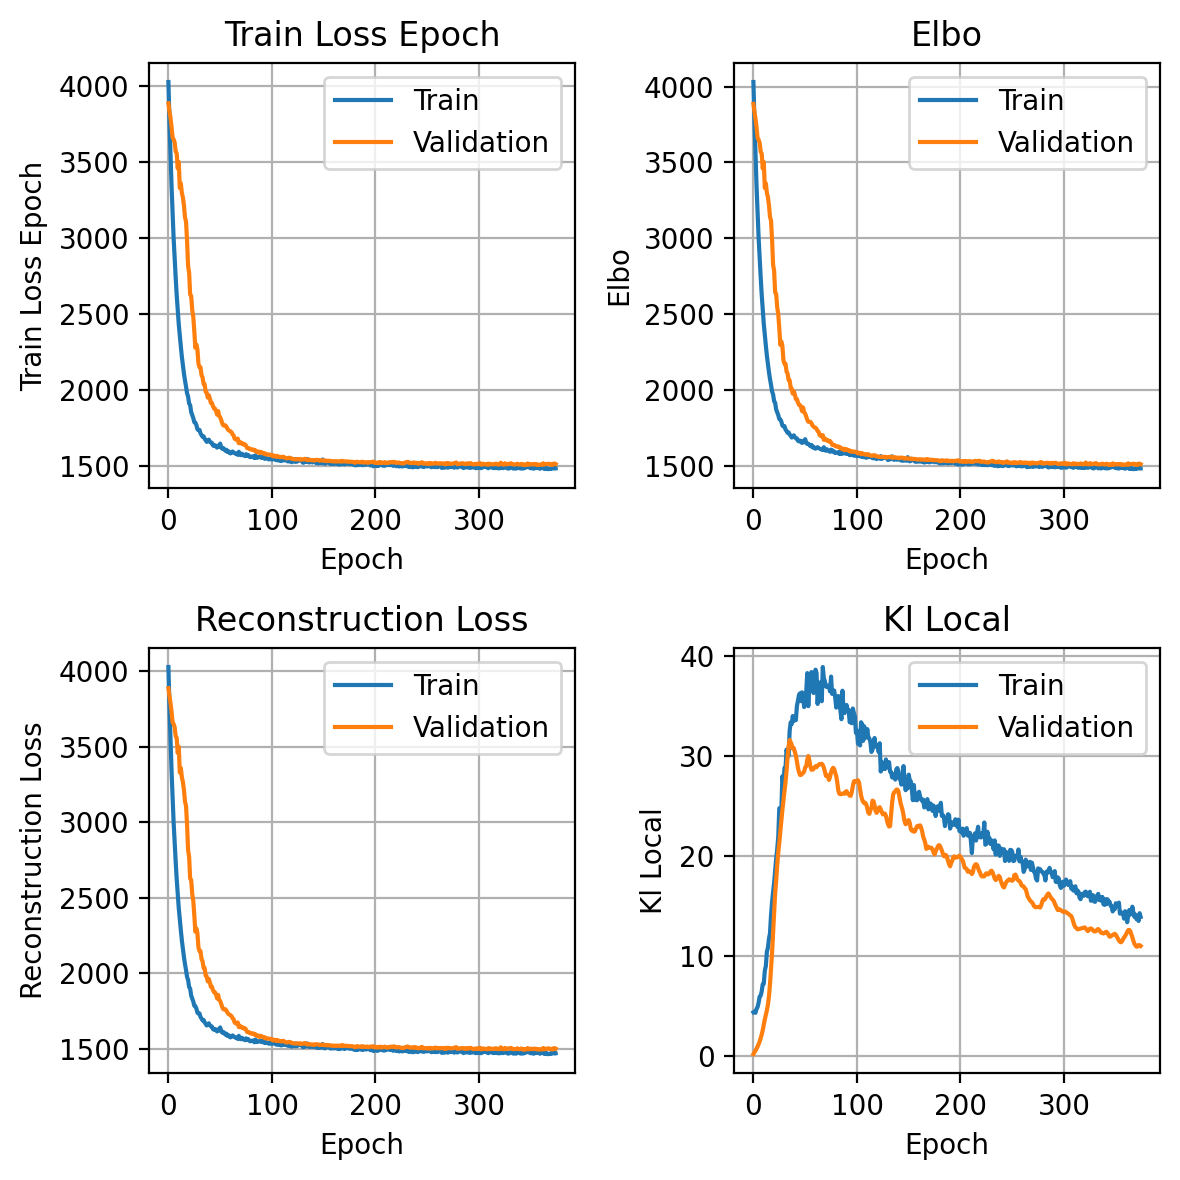

CPU times: user 15.3 s, sys: 186 ms, total: 15.5 s
Wall time: 16.9 s


In [36]:
%%time
batch_key = "batch"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=30,
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-3},
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


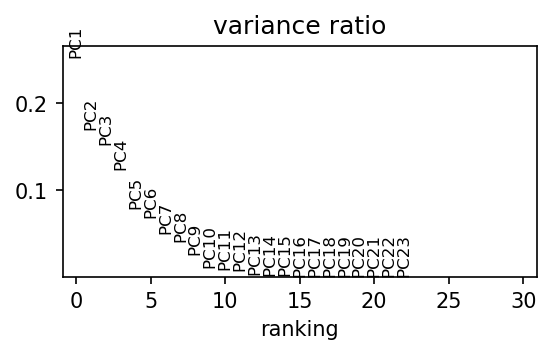

CPU times: user 101 ms, sys: 25.1 ms, total: 126 ms
Wall time: 134 ms


In [37]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

In [38]:
embed.obs["label"] = embed.obs["label"].astype("string").fillna("Unknown").astype("category")

... storing 'group' as categorical
... storing 'phase' as categorical


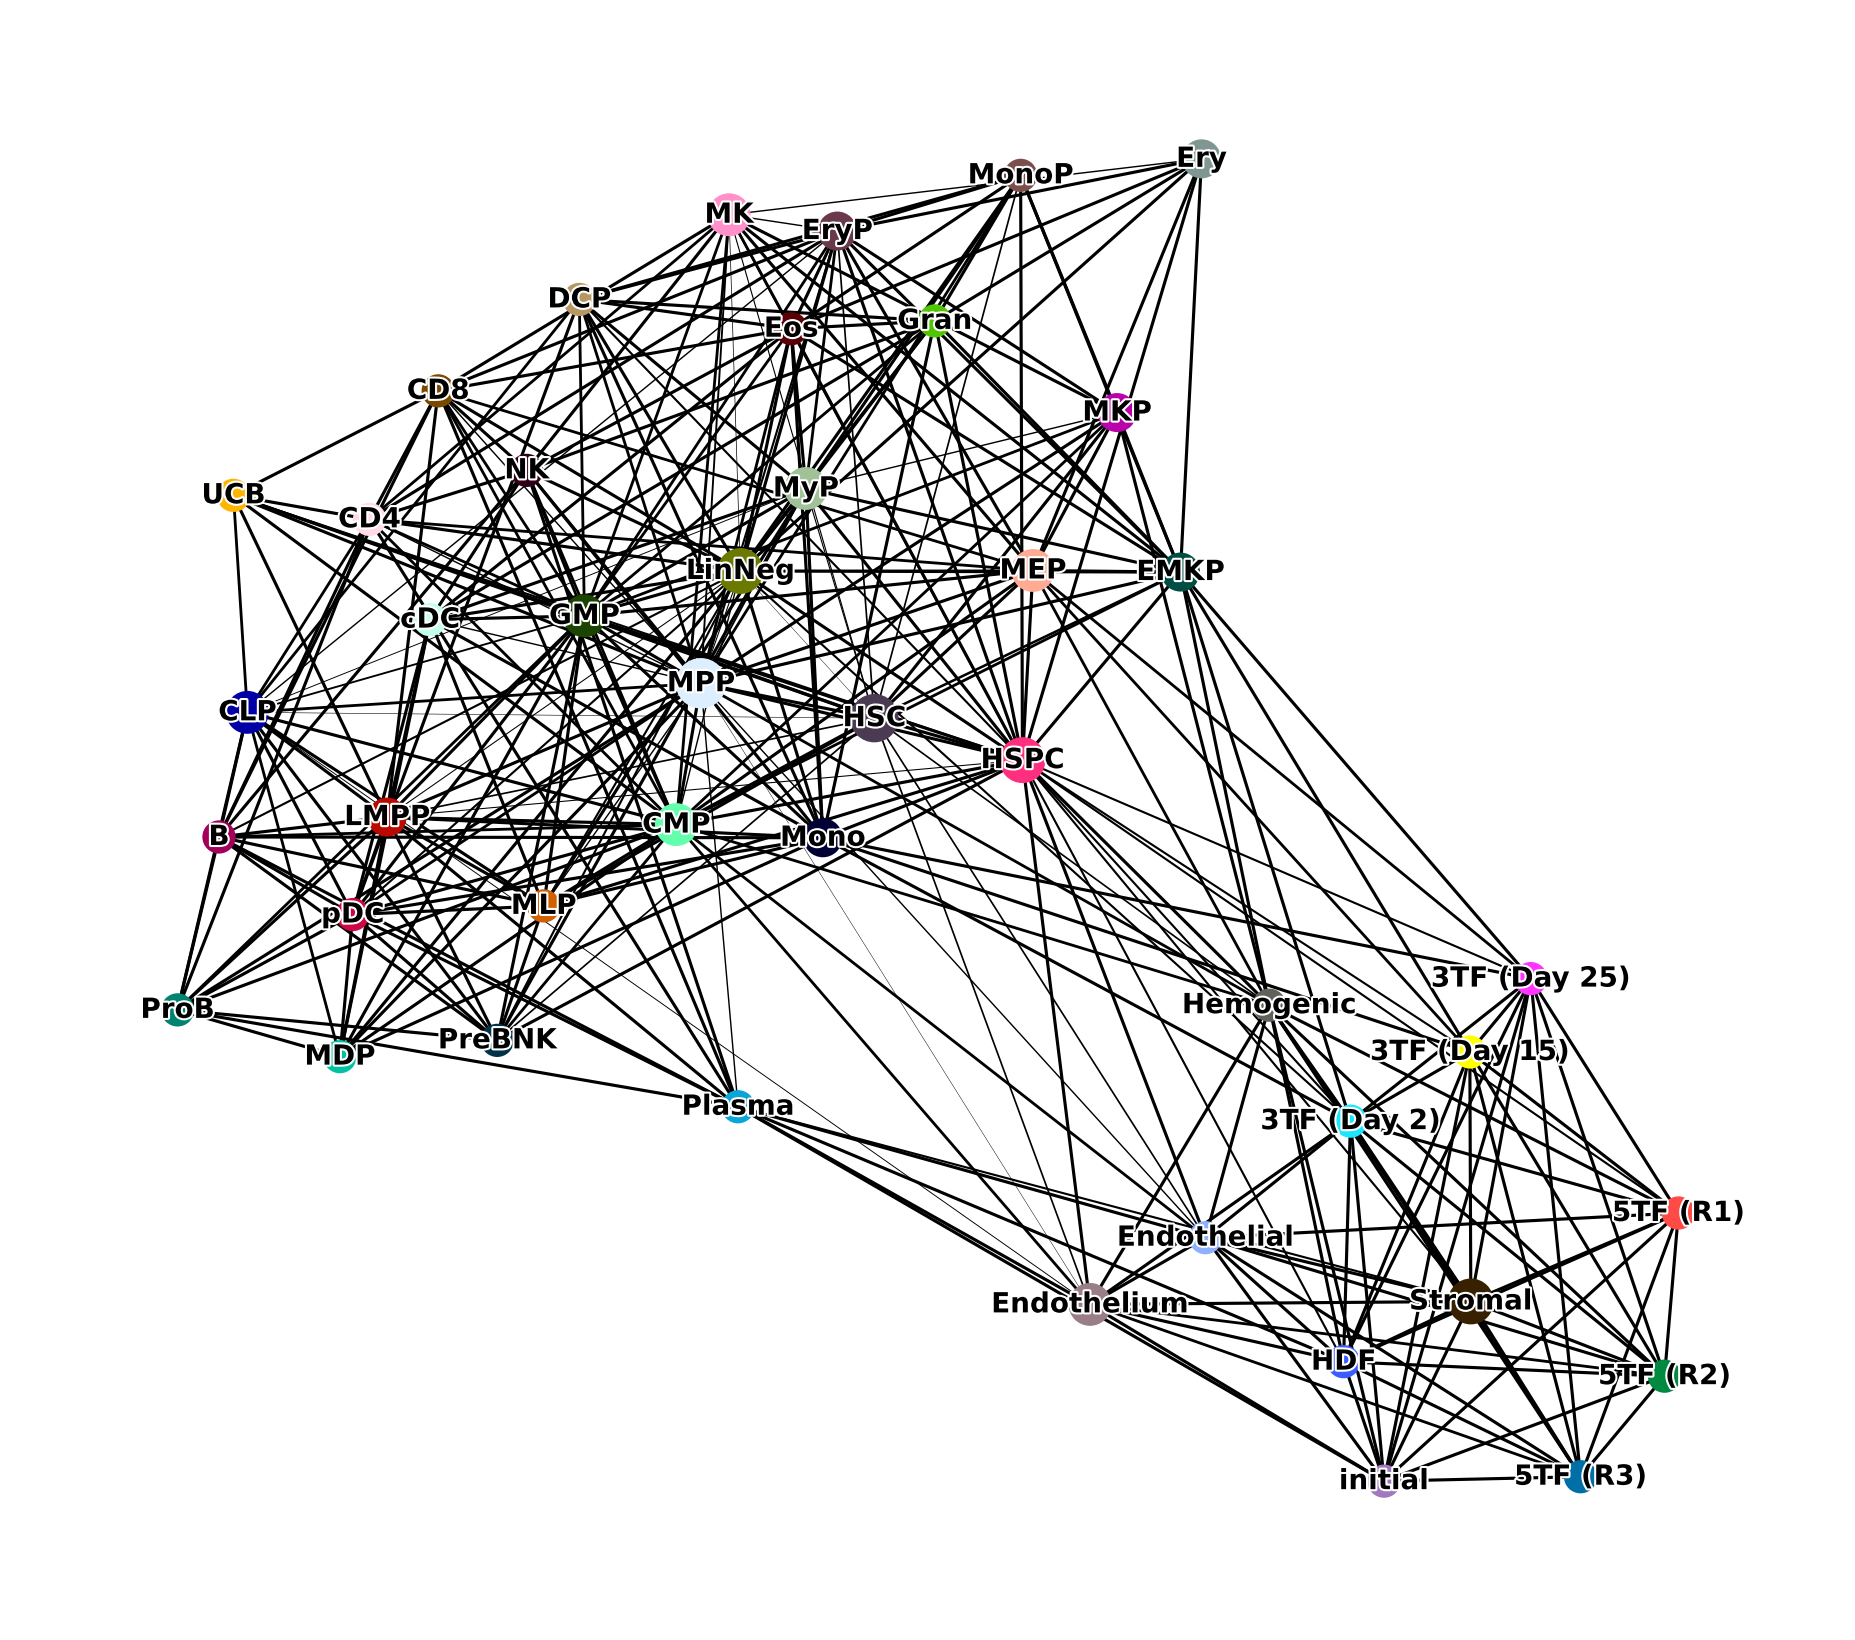

CPU times: user 346 ms, sys: 9.87 ms, total: 356 ms
Wall time: 374 ms


In [39]:
%%time
n_neighbors = 15
paga_group_column = "label"
n_pcs = 50

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.15,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

In [47]:
%%time
X = embed.obsm['X_pca']
print(f"{X.shape=}")

metric = 'cosine'

dists = pairwise_distances(X, metric=metric)
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=embed.obs['label'].values,
    columns=embed.obs['label'].values,
)

df = (df - df.values.min()) / (df.values.max() - df.values.min())

df.head()

X.shape=(82, 23)
dists.shape=(82, 82)
CPU times: user 6.77 ms, sys: 13.5 ms, total: 20.3 ms
Wall time: 69 ms


,CLP,CMP,GMP,HSC,LMPP,MEP,MPP,5TF (R1),5TF (R2),5TF (R3),...,Mono,Gran,CLP,DCP,EryP,MPP,HSC,MKP,MonoP,MyP
CLP,1.940586e-07,2.991176e-01,5.055996e-01,3.951828e-01,4.640706e-01,0.471946,0.312965,0.783070,0.759994,0.752197,...,0.696830,0.795783,0.150968,0.535394,0.646261,0.580800,0.574999,0.662556,0.658254,0.629376
CMP,2.991176e-01,2.587448e-07,2.352658e-01,7.197852e-02,1.646343e-01,0.304181,0.007294,0.920783,0.896368,0.892571,...,0.736883,0.791624,0.529922,0.725246,0.733531,0.526254,0.410056,0.698235,0.676200,0.622685
GMP,5.055996e-01,2.352658e-01,2.264017e-07,3.461630e-01,7.716528e-02,0.207507,0.242872,0.789332,0.759639,0.757748,...,0.672647,0.545163,0.669044,0.574265,0.458729,0.519234,0.531255,0.478433,0.436051,0.477448
HSC,3.951828e-01,7.197852e-02,3.461630e-01,2.910880e-07,3.499249e-01,0.216115,0.041947,0.843682,0.830473,0.836245,...,0.828356,0.837790,0.596227,0.859687,0.678133,0.528857,0.346050,0.593366,0.751843,0.657534
LMPP,4.640706e-01,1.646343e-01,7.716528e-02,3.499249e-01,2.264017e-07,0.373380,0.195508,0.855253,0.830743,0.823306,...,0.546016,0.508031,0.615724,0.470141,0.554178,0.451001,0.483915,0.648991,0.390284,0.430233


In [48]:
pdf = df.copy()
pdf = pdf.loc[['5TF (R1)','5TF (R2)', '5TF (R3)']].T
pdf = pdf.reset_index(names='target_type')
pdf['dataset'] = adata.obs['batch'].values
#pdf = pdf[pdf['dataset'] != 'Our data']
pdf = pd.melt(pdf, id_vars=['target_type', 'dataset'])
pdf['target_type'] = pdf['target_type'].astype(str)
pdf['dataset'] = pdf['dataset'].astype(str)
pdf['variable'] = pdf['variable'].astype(str)
pdf

,target_type,dataset,variable,value
0,CLP,Our data,5TF (R1),0.783070
1,CMP,Our data,5TF (R1),0.920783
2,GMP,Our data,5TF (R1),0.789332
3,HSC,Our data,5TF (R1),0.843682
4,LMPP,Our data,5TF (R1),0.855253
...,...,...,...,...
241,MPP,Setty 2019,5TF (R3),0.697694
242,HSC,Setty 2019,5TF (R3),0.718892
243,MKP,Setty 2019,5TF (R3),0.463897
244,MonoP,Setty 2019,5TF (R3),0.656815


Georgolopoulos 2021 21 4


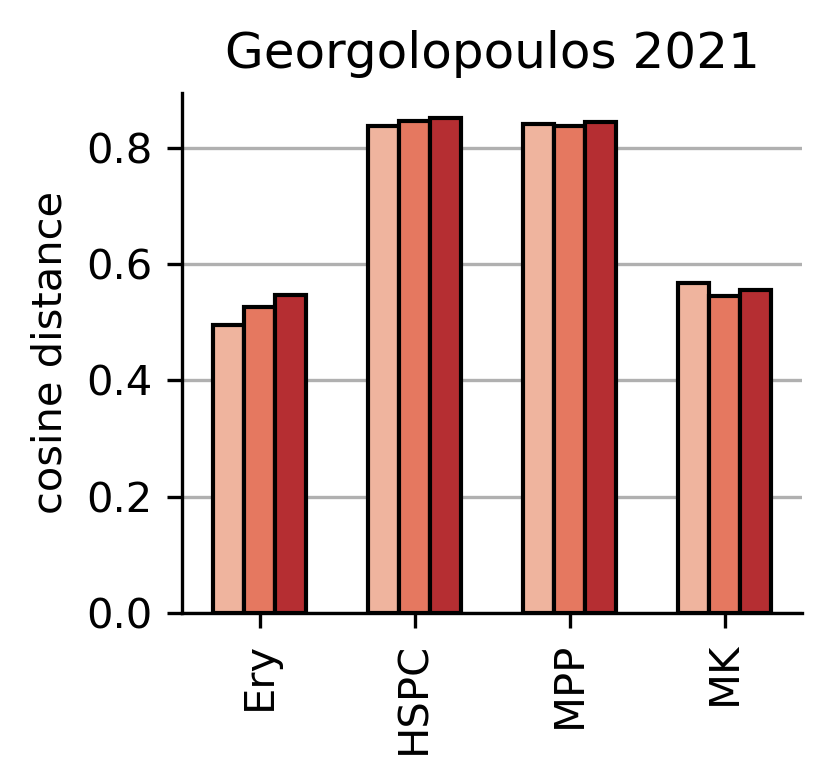

Gomes 2018 15 5


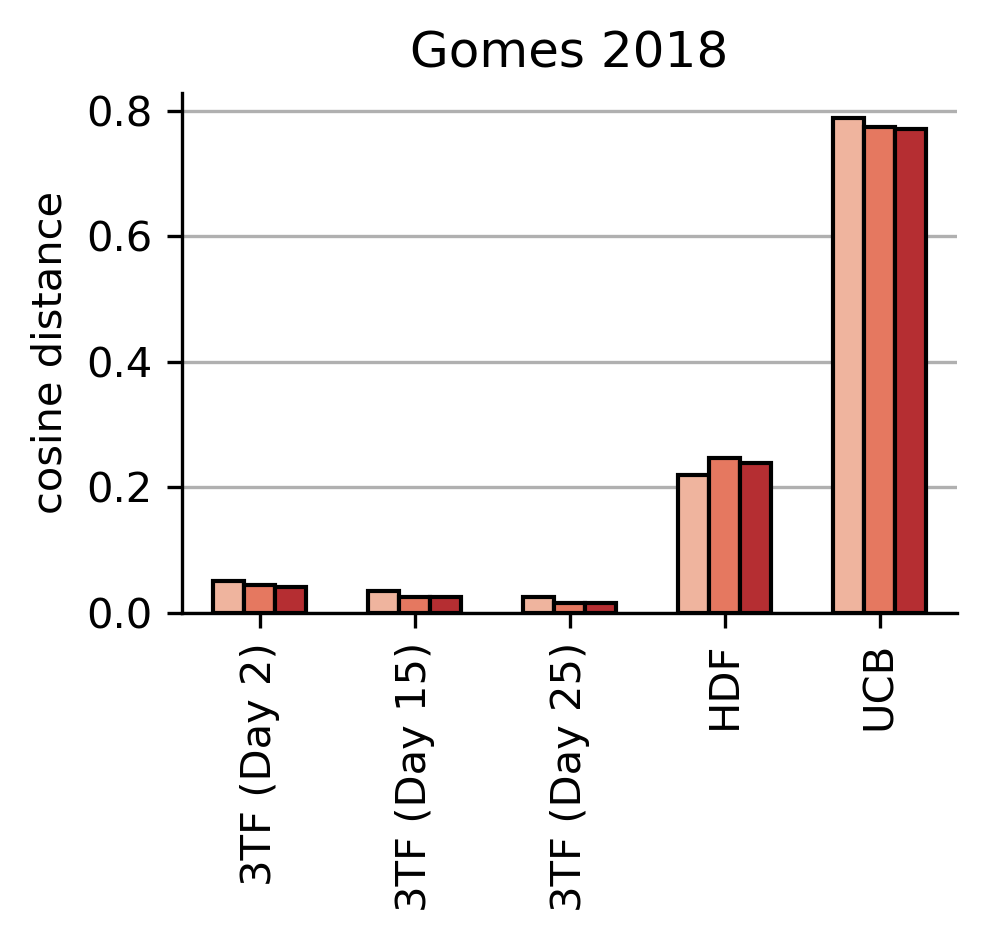

Ng 2024 60 11


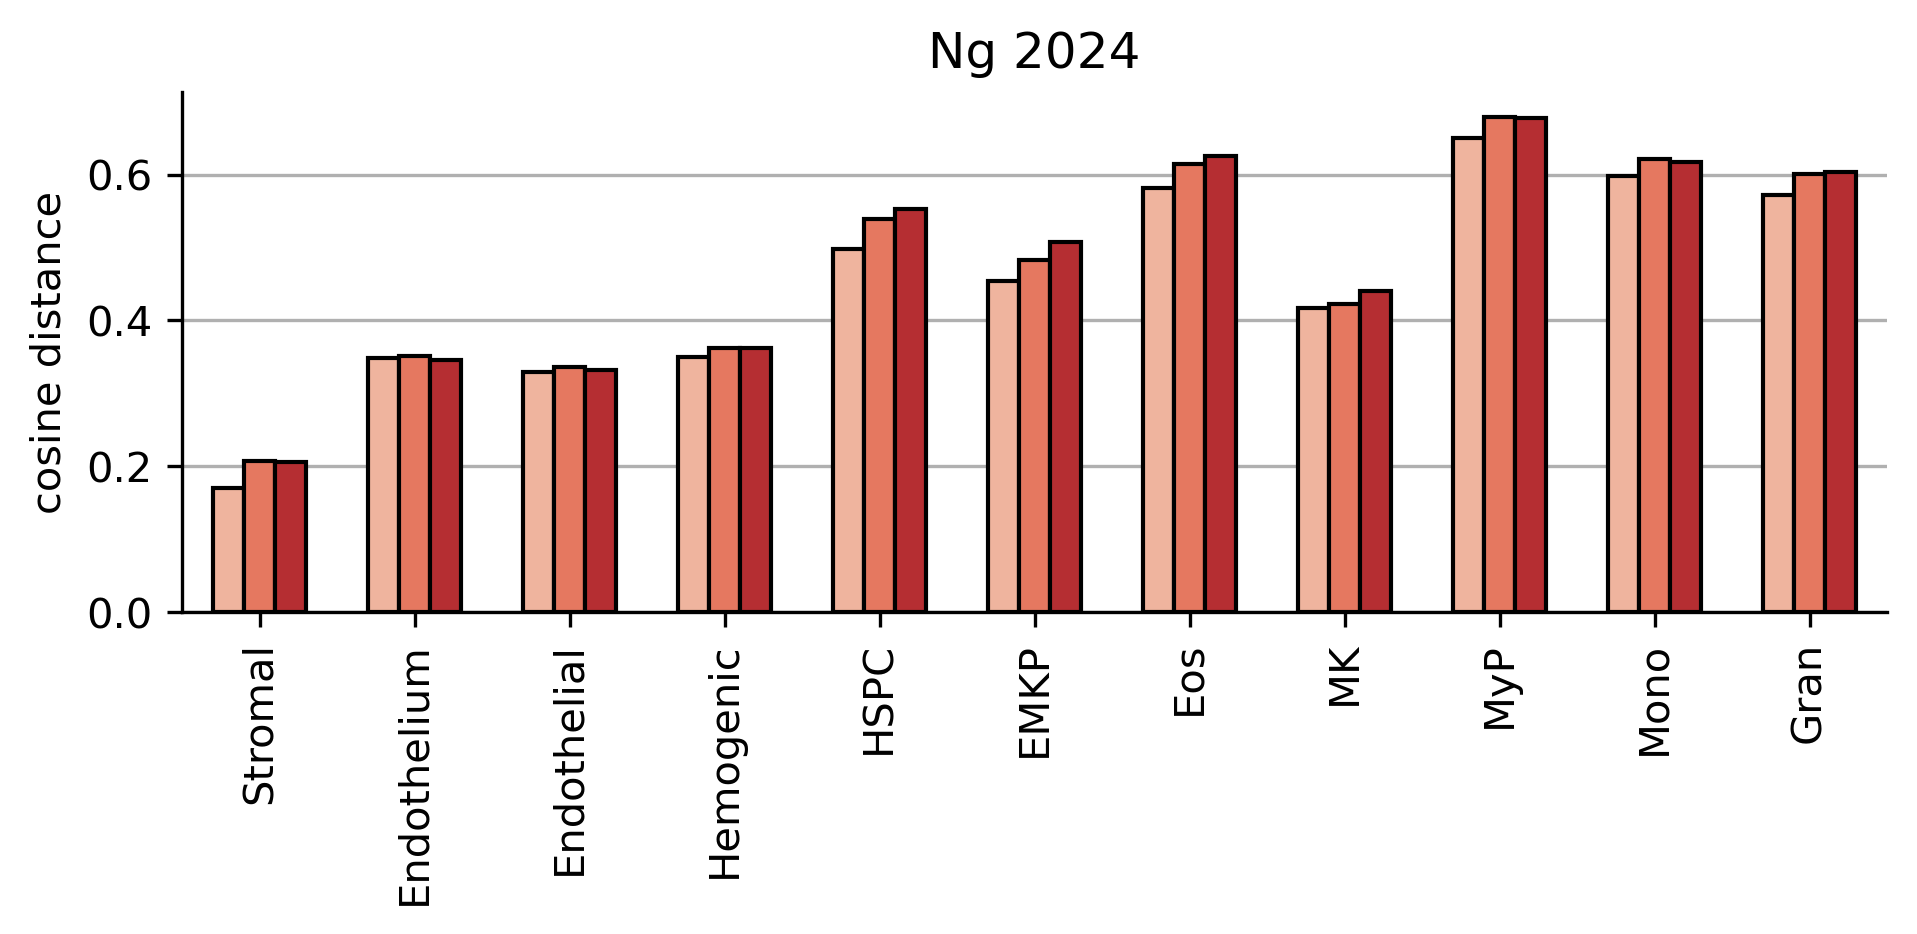

Pellin 2019 33 8


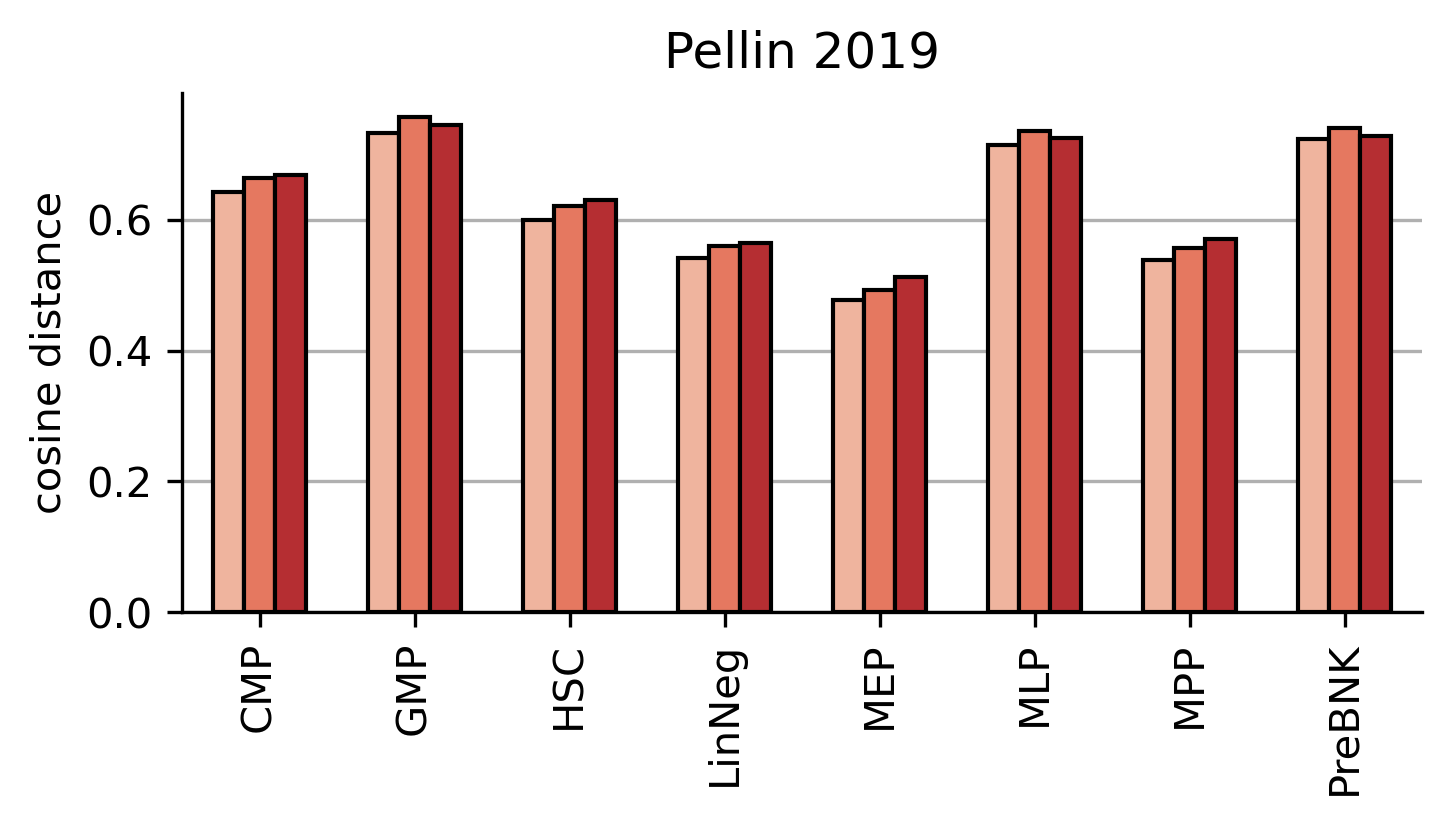

Setty 2019 24 8


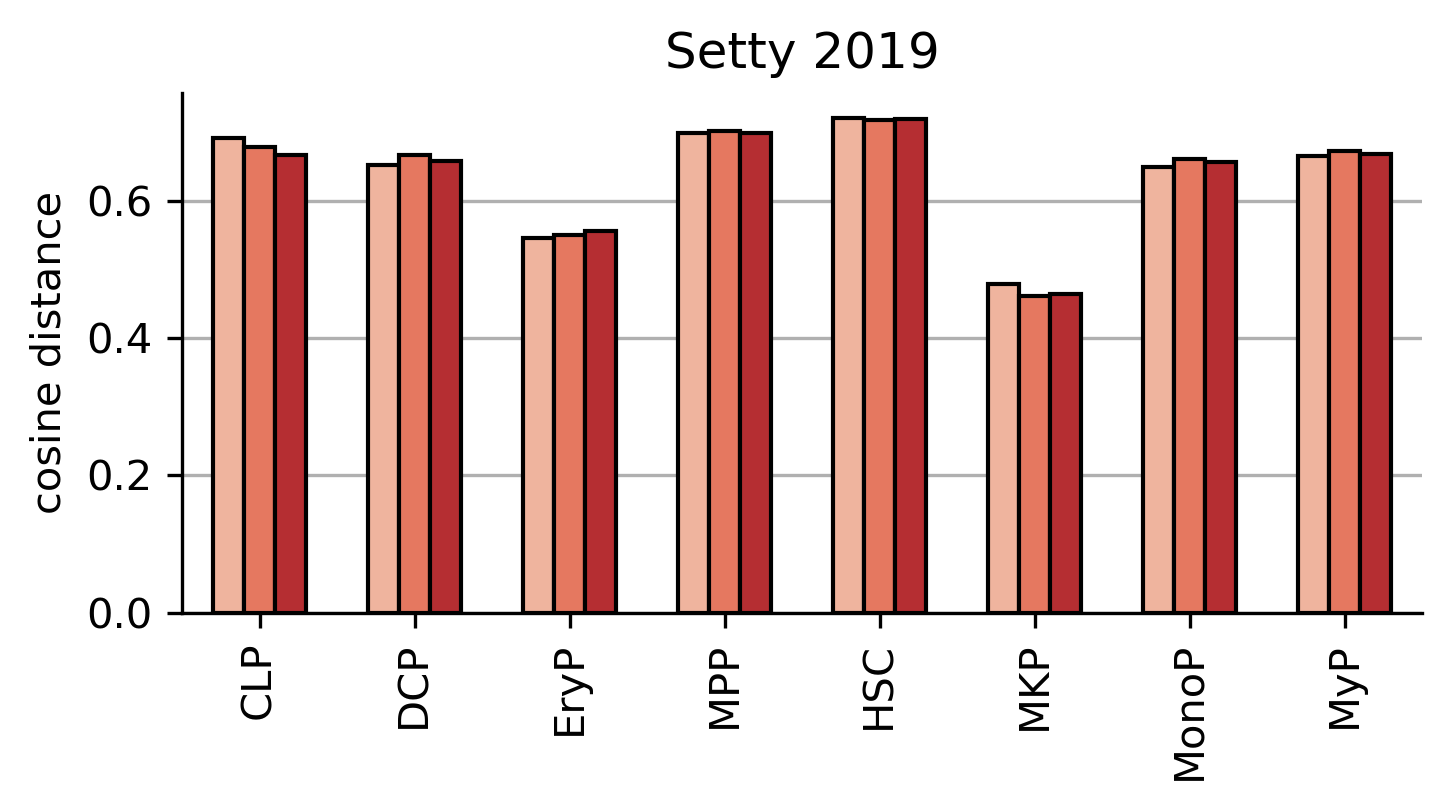

This Study 33 11


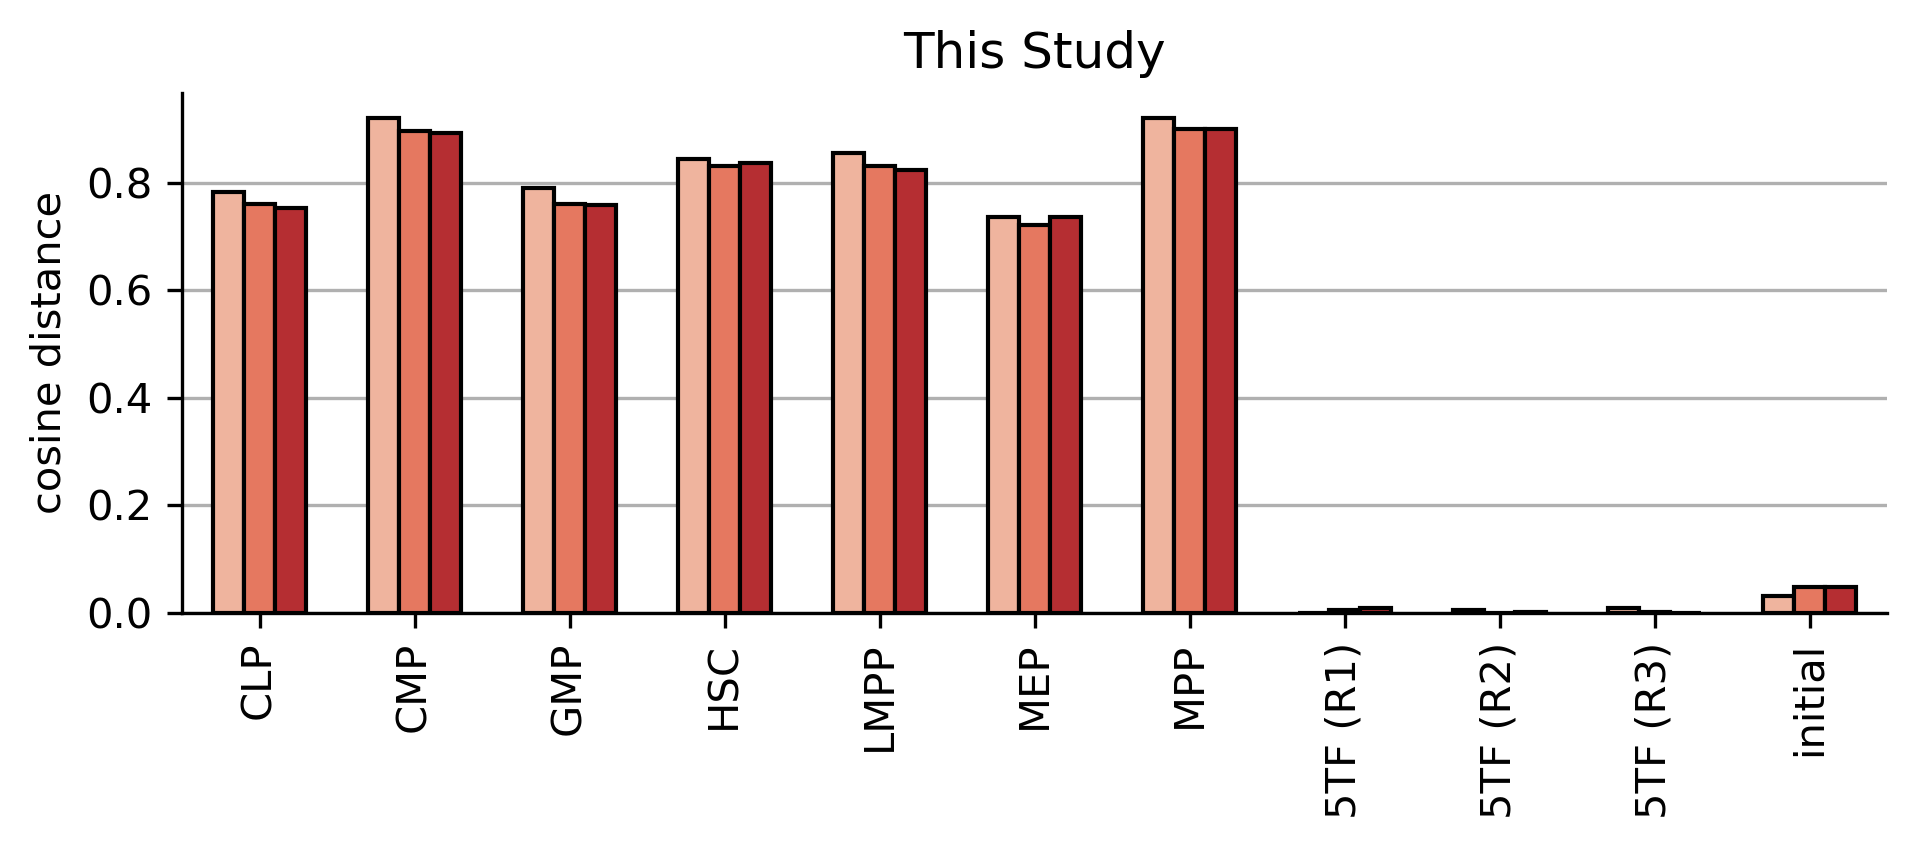

Weng 2024 60 19


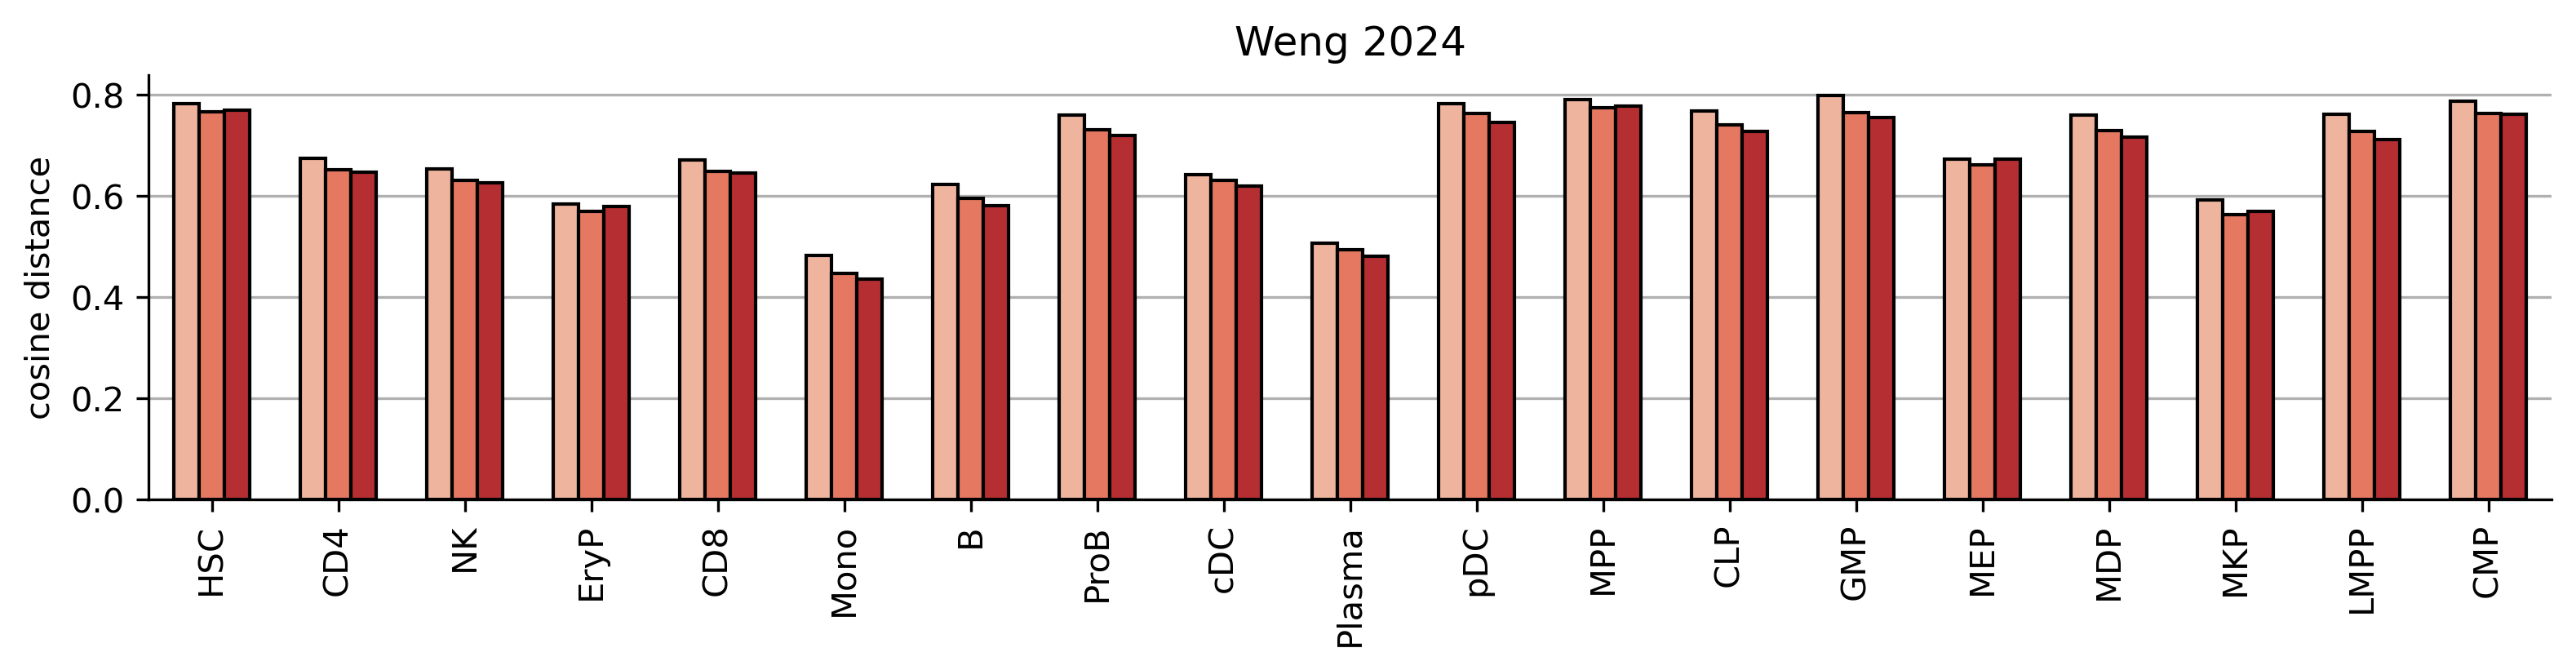

In [49]:
palette = {
    '5TF (R1)'      : '#FCAE91',
    '5TF (R2)'      : '#FB6A4A',
    '5TF (R3)'      : '#CB181D',
}

pdf['dataset'] = np.where(pdf['dataset'] == 'Our data', 'This Study', pdf['dataset'])

for dataname, group in pdf.groupby('dataset', observed=True):
    print(dataname, len(group), group['target_type'].nunique())

    x_length = group['target_type'].nunique()

    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = x_length / 1.5, 2.25

    sns.barplot(
        data=group,
        x='target_type',
        y='value',
        hue='variable',
        width=0.6,
        palette=palette,#['#02A679', '#D55E00', '#F9CF86'],
        ec='k',
        zorder=2,
        errorbar=None,
        legend=False,
    )

    plt.xticks(rotation=90)
    plt.grid(axis='y', zorder=0)
    plt.title(dataname)
    plt.xlabel("")
    plt.ylabel(f'{metric} distance')
    # sns.move_legend(
    #     plt.gca(),
    #     loc='upper center',
    #     title="",
    #     frameon=False,
    #     ncols=3,
    #     bbox_to_anchor=(0.5, 1.35),
    # )
    sns.despine()
    plt.show()
    
    # break


In [26]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

HSC 15 4


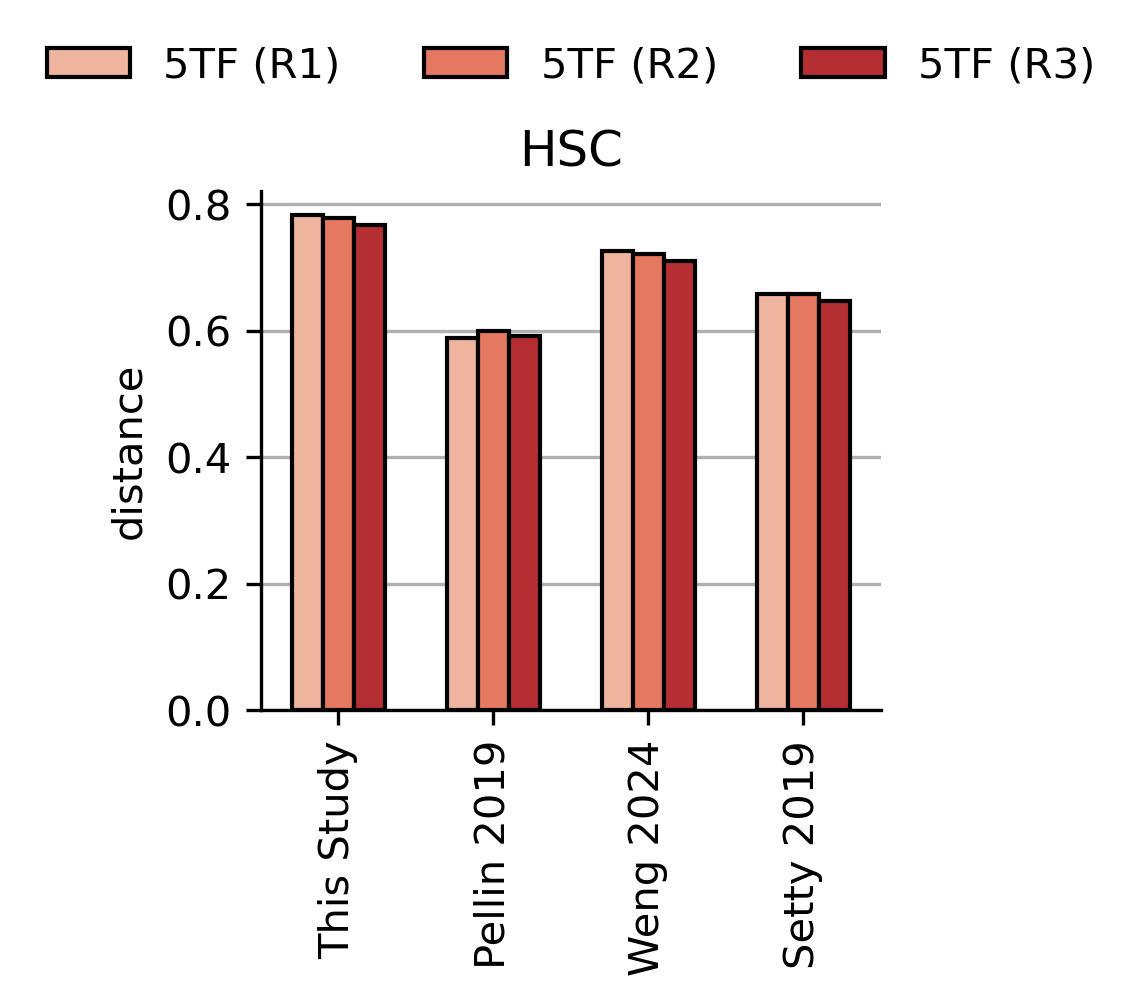

HSPC 12 2


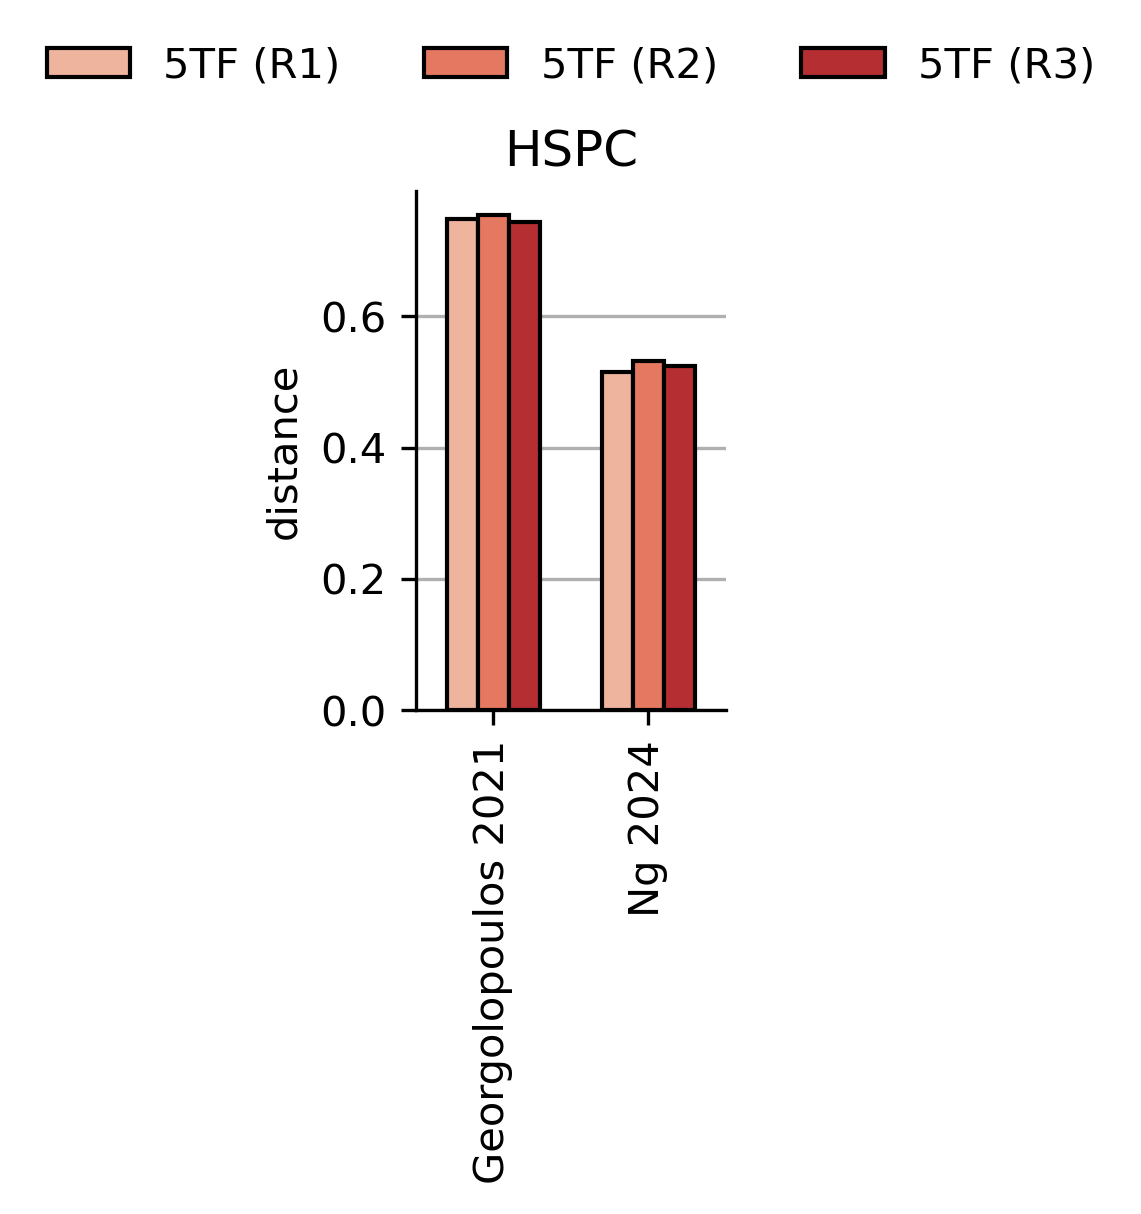

UCB 3 1


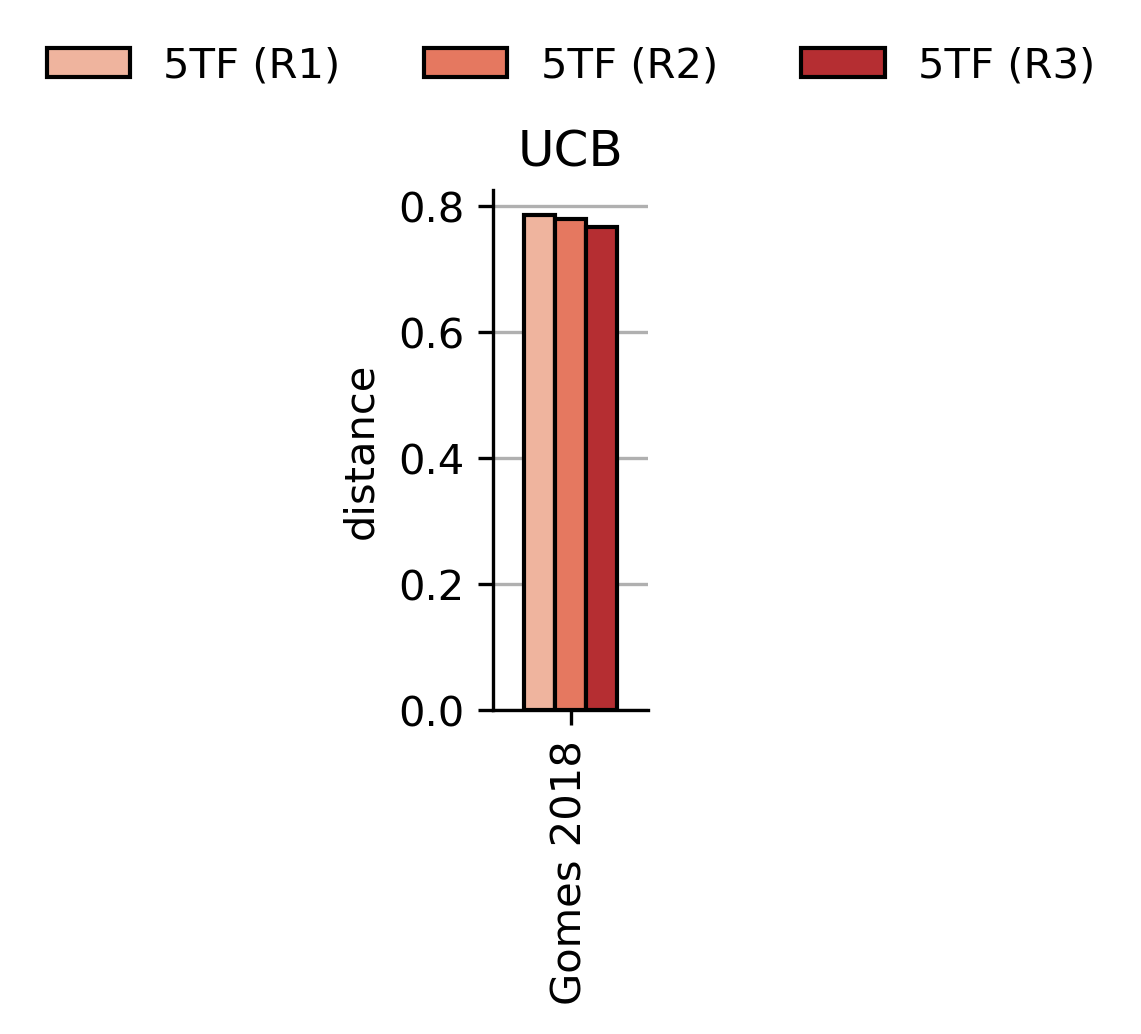

In [44]:
for t_type, group in pdf.groupby('target_type', observed=True):
    if t_type not in ["HSC", "HSPC", "UCB"]:
        continue
    else:
        print(t_type, len(group), group['dataset'].nunique())

        x_length = group['dataset'].nunique()

        plt.rcParams['figure.dpi'] = 300
        plt.rcParams['figure.figsize'] = x_length / 1.5, 2.25

        sns.barplot(
            data=group,
            x='dataset',
            y='value',
            hue='variable',
            width=0.6,
            palette=palette,#['#02A679', '#D55E00', '#F9CF86'],
            ec='k',
            zorder=2,
            errorbar=None,
            #legend=False,
        )

        plt.xticks(rotation=90)
        plt.grid(axis='y', zorder=0)
        plt.title(t_type)
        plt.xlabel("")
        plt.ylabel('distance')
        sns.move_legend(
            plt.gca(),
            loc='upper center',
            title="",
            frameon=False,
            ncols=3,
            bbox_to_anchor=(0.5, 1.35),
        )
        sns.despine()
        plt.show()
    
    # break
  

In [50]:
target_types = ['HSC', 'HSPC', '3TF (Day 25)']

tmp = pdf[pdf['target_type'].isin(target_types)].copy()

tmp = tmp[tmp['dataset'] != 'Georgolopoulos 2021']

# tmp['dataset'] = np.where(tmp['dataset'] == 'Our data', 'This Study', tmp['dataset'])

tmp.head()

,target_type,dataset,variable,value
3,HSC,This Study,5TF (R1),0.843682
13,3TF (Day 25),Gomes 2018,5TF (R1),0.024861
18,HSC,Pellin 2019,5TF (R1),0.599936
34,HSC,Weng 2024,5TF (R1),0.772748
45,HSC,Weng 2024,5TF (R1),0.790524


In [24]:
tmp['variable'].value_counts()

variable
5TF (R1)    10
5TF (R2)    10
5TF (R3)    10
Name: count, dtype: int64

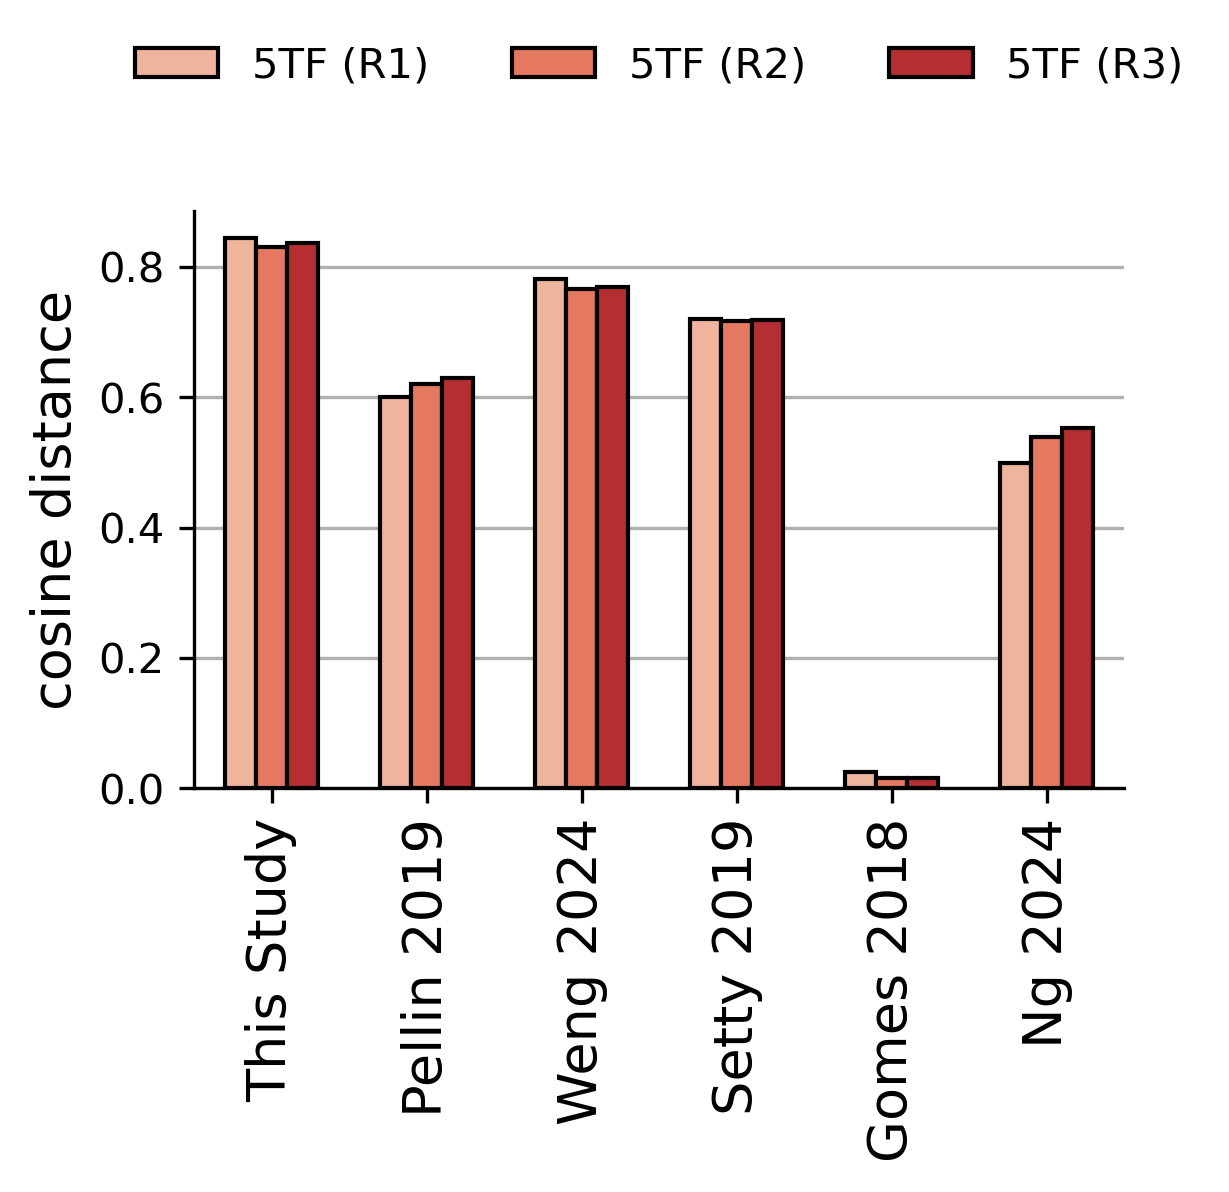

In [51]:
x_length = tmp['dataset'].nunique()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = x_length / 1.5, 2.5

palette = {
    '5TF (R1)'      : '#FCAE91',
    '5TF (R2)'      : '#FB6A4A',
    '5TF (R3)'      : '#CB181D',
}

plot_order = [
    'This Study',
    'Pellin 2019',
    'Weng 2024',
    'Setty 2019',
    'Gomes 2018',
    'Ng 2024',
]

sns.barplot(
    data=tmp,
    x='dataset',
    y='value',
    hue='variable',
    order=plot_order,
    width=0.6,
    palette=palette,#['#02A679', '#D55E00', '#F9CF86'],
    ec='k',
    zorder=2,
    errorbar=None,
    #legend=False,
)

plt.xticks(rotation=90, fontsize=13)
plt.grid(axis='y', zorder=0)
plt.xlabel("")
plt.ylabel(f'{metric} distance', fontsize=13)
sns.move_legend(
    plt.gca(),
    loc='upper center',
    title="",
    frameon=False,
    ncols=3,
    bbox_to_anchor=(0.5, 1.35),
)
sns.despine()
plt.show()